
# 03 - Exploratory Data Analysis

Exploratory analysis on cleaned OpenSky data covering trends, distributions, outliers, segment comparison, and relationships.


In [1]:

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 200)
pd.set_option('display.float_format', lambda x: f"{x:,.3f}")

sns.set_theme(style="whitegrid", context="notebook")


## 1) Load Cleaned Dataset

In [2]:

# Try both naming conventions observed in the repository
candidate_paths = [
    Path('../Data/processed/cleaned_dataset.csv'),
    Path('../data/processed/cleaned_dataset.csv'),
    Path('Data/processed/cleaned_dataset.csv'),
    Path('data/processed/cleaned_dataset.csv'),
]

source_path = None
for path in candidate_paths:
    if path.exists():
        source_path = path
        break

if source_path is None:
    raise FileNotFoundError('Could not locate cleaned_dataset.csv in expected processed folders.')

df = pd.read_csv(source_path)
print(f"Loaded: {source_path}")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")


Loaded: ../Data/processed/cleaned_dataset.csv
Shape: 106,795 rows x 14 columns


## 2) Schema, Types, and Data Quality Snapshot

In [3]:

# Parse temporal fields
if 'collection_time' in df.columns:
    df['collection_time'] = pd.to_datetime(df['collection_time'], errors='coerce')

if 'time_position' in df.columns:
    df['time_position_dt'] = pd.to_datetime(df['time_position'], unit='s', errors='coerce')

if 'last_contact' in df.columns:
    df['last_contact_dt'] = pd.to_datetime(df['last_contact'], unit='s', errors='coerce')

print('Column dtypes:')
display(df.dtypes.to_frame('dtype').T)

print('\nMissing values (top):')
display(df.isna().sum().sort_values(ascending=False).head(10).to_frame('null_count'))

print('\nSample rows:')
display(df.head(5))


Column dtypes:


,icao24,callsign,origin_country,time_position,last_contact,longitude,latitude,baro_altitude,on_ground,velocity,heading,vertical_rate,geo_altitude,collection_time,time_position_dt,last_contact_dt
dtype,object,object,object,float64,int64,float64,float64,float64,bool,float64,float64,float64,float64,datetime64[ns],datetime64[ns],datetime64[ns]



Missing values (top):


,null_count
icao24,0
callsign,0
origin_country,0
time_position,0
last_contact,0
longitude,0
latitude,0
baro_altitude,0
on_ground,0
velocity,0



Sample rows:


,icao24,callsign,origin_country,time_position,last_contact,longitude,latitude,baro_altitude,on_ground,velocity,heading,vertical_rate,geo_altitude,collection_time,time_position_dt,last_contact_dt
0,511142,DMS1,Estonia,"1,776,336,263.000",1776336263,17.628,49.481,"2,529.840",False,93.230,42.320,-3.900,"2,628.900",2026-04-16 10:44:42.038813,2026-04-16 10:44:23,2026-04-16 10:44:23
1,39de4e,TVF49MD,France,"1,776,336,263.000",1776336263,9.165,42.746,"11,277.600",False,229.360,126.150,-0.330,"11,513.820",2026-04-16 10:44:42.038813,2026-04-16 10:44:23,2026-04-16 10:44:23
2,3ffc29,DMFSS,Germany,"1,776,336,262.000",1776336263,11.736,50.795,"1,173.480",False,54.700,163.610,-0.330,"9,235.440",2026-04-16 10:44:42.038813,2026-04-16 10:44:22,2026-04-16 10:44:23
3,ab1644,Unknown,United States,"1,776,336,225.000",1776336225,-74.183,40.682,"8,877.300",True,1.290,90.000,0.000,"9,235.440",2026-04-16 10:44:42.038813,2026-04-16 10:43:45,2026-04-16 10:43:45
4,80162d,AXB1527,India,"1,776,336,263.000",1776336263,77.299,25.899,"12,192.000",False,234.170,1.640,0.000,"12,740.640",2026-04-16 10:44:42.038813,2026-04-16 10:44:23,2026-04-16 10:44:23


## 3) High-Level KPI Snapshot

In [4]:

kpi = {
    'total_records': len(df),
    'unique_aircraft_icao24': df['icao24'].nunique() if 'icao24' in df.columns else np.nan,
    'unique_countries': df['origin_country'].nunique() if 'origin_country' in df.columns else np.nan,
    'airborne_pct': ((~df['on_ground']).mean() * 100) if 'on_ground' in df.columns else np.nan,
    'avg_velocity': df['velocity'].mean() if 'velocity' in df.columns else np.nan,
    'median_velocity': df['velocity'].median() if 'velocity' in df.columns else np.nan,
    'avg_geo_altitude': df['geo_altitude'].mean() if 'geo_altitude' in df.columns else np.nan,
}

kpi_df = pd.Series(kpi, name='value').to_frame()
display(kpi_df)


,value
total_records,"106,795.000"
unique_aircraft_icao24,"7,476.000"
unique_countries,97.000
airborne_pct,90.830
avg_velocity,162.862
median_velocity,201.240
avg_geo_altitude,"7,504.956"



## 4) Trend Analysis

Time window is short, so trends are interpreted at minute granularity.


,minute,records,airborne_pct,avg_velocity,avg_geo_altitude
0,2026-04-16 10:39:00,158,70.886,98.139,"6,280.134"
1,2026-04-16 10:40:00,792,76.010,98.179,"5,708.967"
2,2026-04-16 10:41:00,1604,76.995,111.118,"6,109.012"
3,2026-04-16 10:42:00,2007,62.282,78.098,"6,252.637"
4,2026-04-16 10:43:00,2687,73.018,95.182,"5,748.421"


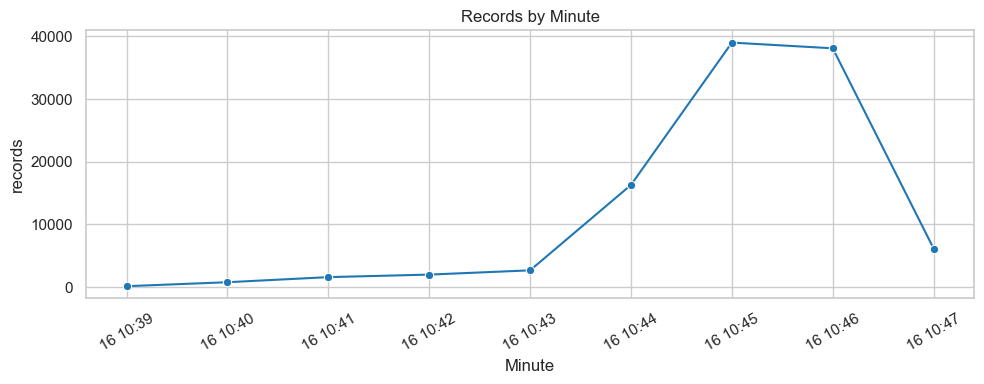

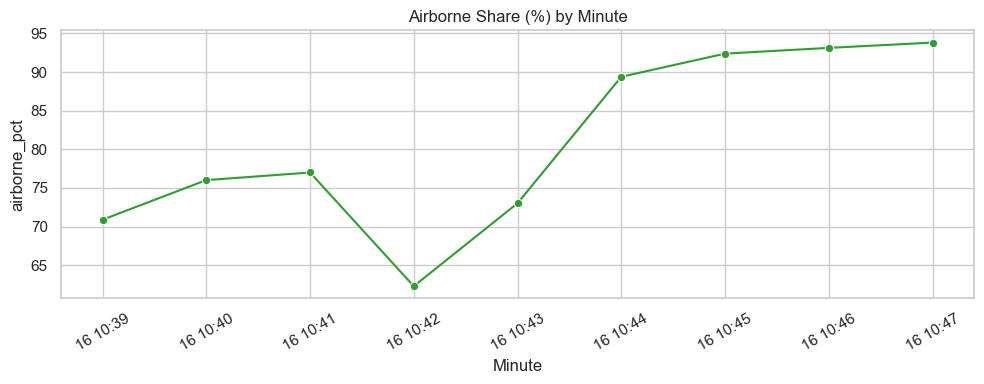

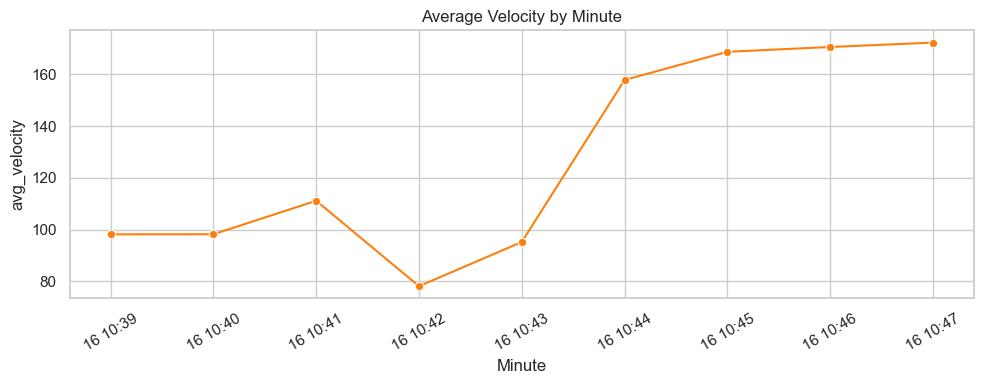

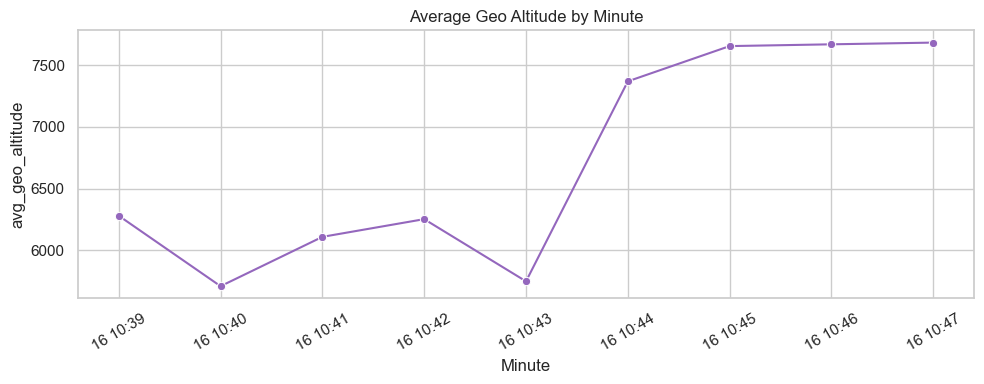

In [5]:

time_col = 'last_contact_dt' if 'last_contact_dt' in df.columns else 'collection_time'

trend = (
    df.assign(minute=df[time_col].dt.floor('min'))
      .groupby('minute', as_index=False)
      .agg(
          records=('icao24', 'size'),
          airborne_pct=('on_ground', lambda s: (~s).mean() * 100),
          avg_velocity=('velocity', 'mean'),
          avg_geo_altitude=('geo_altitude', 'mean')
      )
      .sort_values('minute')
)

display(trend.head())

trend_specs = [
    ('records', 'Records by Minute', '#1f77b4'),
    ('airborne_pct', 'Airborne Share (%) by Minute', '#2ca02c'),
    ('avg_velocity', 'Average Velocity by Minute', '#ff7f0e'),
    ('avg_geo_altitude', 'Average Geo Altitude by Minute', '#9467bd'),
]

for y_col, title, color in trend_specs:
    plt.figure(figsize=(10, 4))
    sns.lineplot(data=trend, x='minute', y=y_col, marker='o', color=color)
    plt.title(title)
    plt.xlabel('Minute')
    plt.ylabel(y_col)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


## 5) Category Comparison: Countries and Flight Phase

,origin_country,record_count
0,United States,30338
1,United Kingdom,7959
2,Ireland,4358
3,Germany,3828
4,Turkey,3690
5,Spain,3541
6,China,3088
7,France,3049
8,Australia,2988
9,Malta,2713


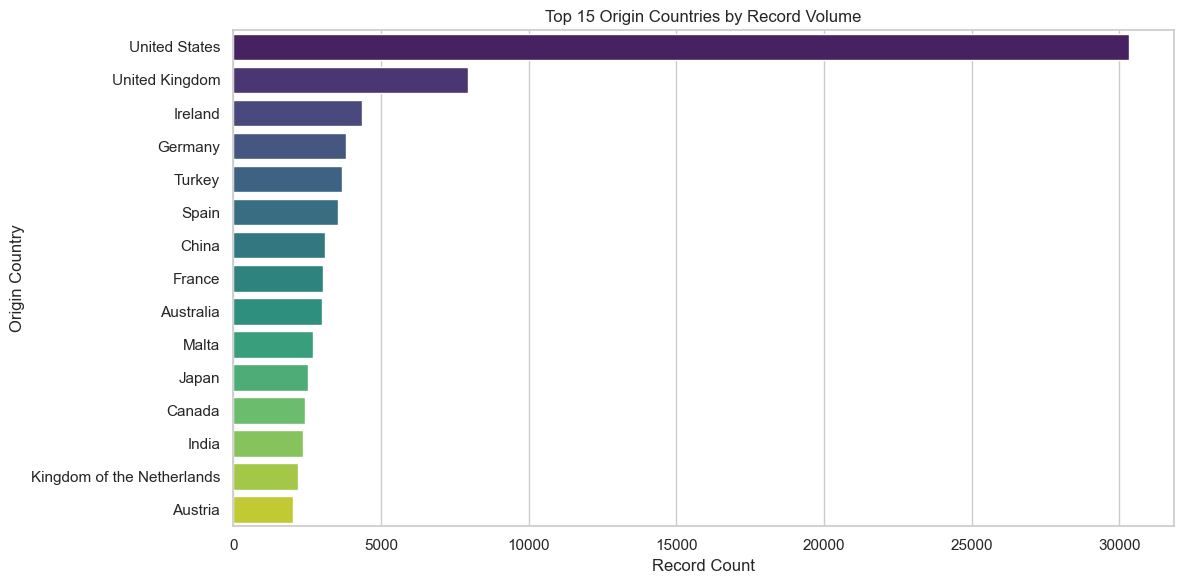

,origin_country,records,airborne_pct,avg_velocity
93,United States,30338,90.550,162.586
92,United Kingdom,7959,93.316,148.211
38,Ireland,4358,94.699,187.932
32,Germany,3828,92.764,112.787
89,Turkey,3690,96.450,200.574
81,Spain,3541,92.008,160.239
19,China,3088,92.973,187.368
30,France,3049,91.374,142.642
4,Australia,2988,76.506,132.652
52,Malta,2713,92.923,184.526


In [6]:

country_counts = (
    df['origin_country']
      .value_counts()
      .head(15)
      .rename_axis('origin_country')
      .reset_index(name='record_count')
)

display(country_counts.head(10))

plt.figure(figsize=(12, 6))
sns.barplot(data=country_counts, y='origin_country', x='record_count', palette='viridis')
plt.title('Top 15 Origin Countries by Record Volume')
plt.xlabel('Record Count')
plt.ylabel('Origin Country')
plt.tight_layout()
plt.show()

country_phase = (
    df.groupby('origin_country', as_index=False)
      .agg(
          records=('icao24', 'size'),
          airborne_pct=('on_ground', lambda s: (~s).mean() * 100),
          avg_velocity=('velocity', 'mean')
      )
      .query('records >= 500')
      .sort_values('records', ascending=False)
      .head(15)
)

display(country_phase)


## 6) Geospatial Coverage (Latitude-Longitude Density)

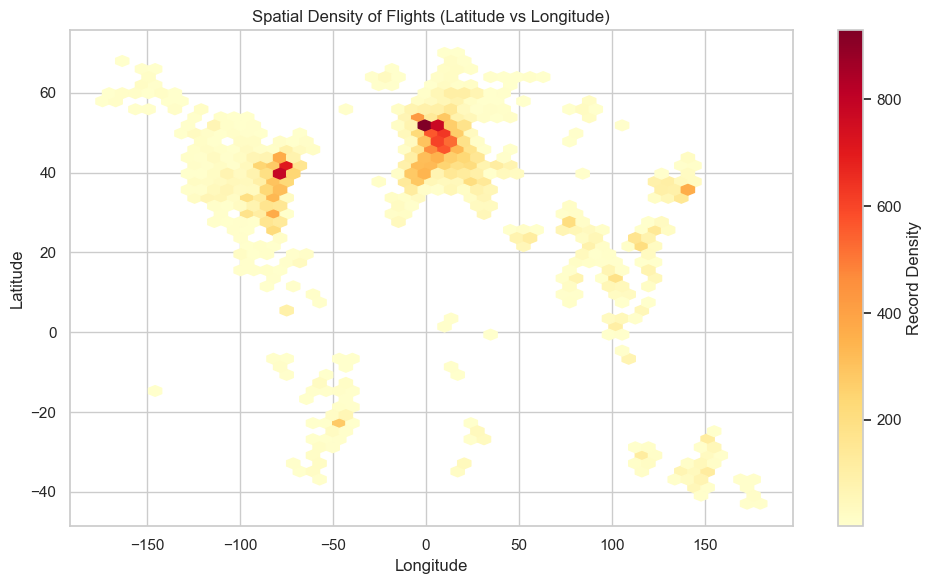

In [7]:

# Sample for plotting efficiency
plot_df = df[['longitude', 'latitude']].dropna().sample(min(30000, len(df)), random_state=42)

plt.figure(figsize=(10, 6))
plt.hexbin(
    plot_df['longitude'],
    plot_df['latitude'],
    gridsize=50,
    cmap='YlOrRd',
    mincnt=1
)
plt.colorbar(label='Record Density')
plt.title('Spatial Density of Flights (Latitude vs Longitude)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()


## 7) Distribution Analysis of Core Numeric Features

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
velocity,"106,795.000",162.862,84.739,0.000,84.360,201.240,228.310,"1,259.640",-0.417,1.754
baro_altitude,"106,795.000","7,239.801","4,153.847",-304.800,"3,009.900","8,877.300","10,965.180","17,404.080",-0.542,-1.261
geo_altitude,"106,795.000","7,504.956","4,197.084",-53.340,"3,238.500","9,235.440","11,094.720","31,211.520",-0.578,-1.205
vertical_rate,"106,795.000",0.079,4.902,-66.000,-0.330,0.000,0.000,106.640,0.641,9.657
heading,"106,795.000",186.837,102.129,0.000,100.300,196.280,274.840,359.870,-0.148,-1.165


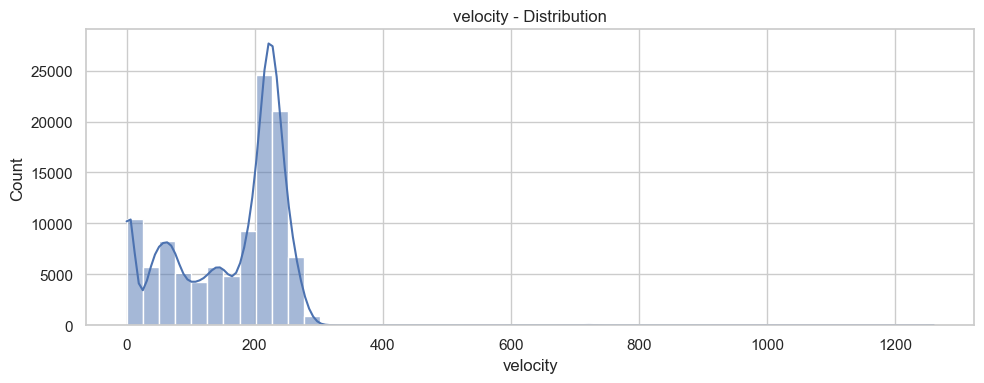

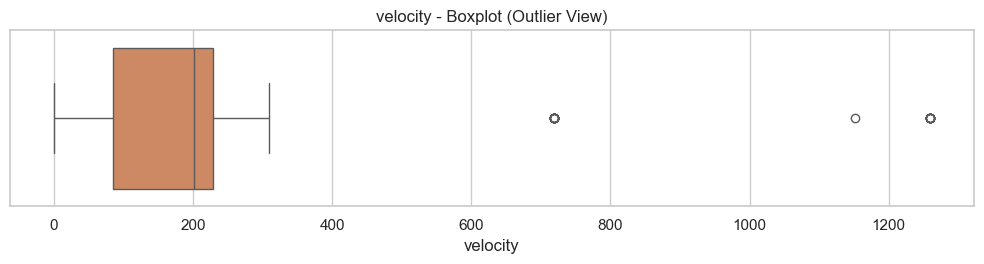

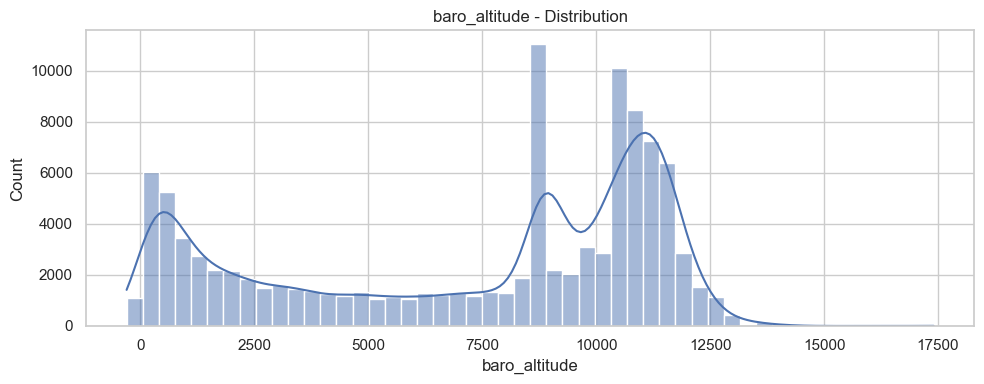

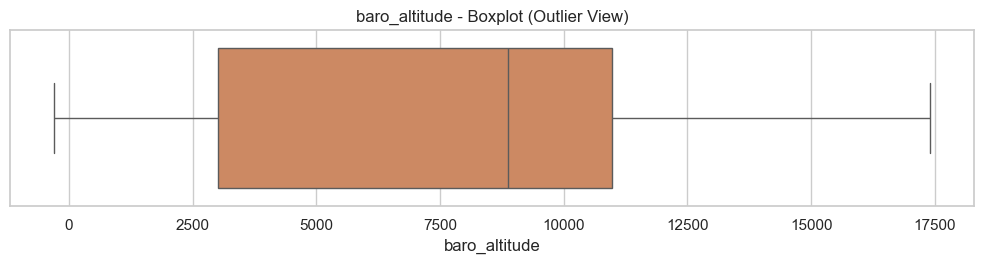

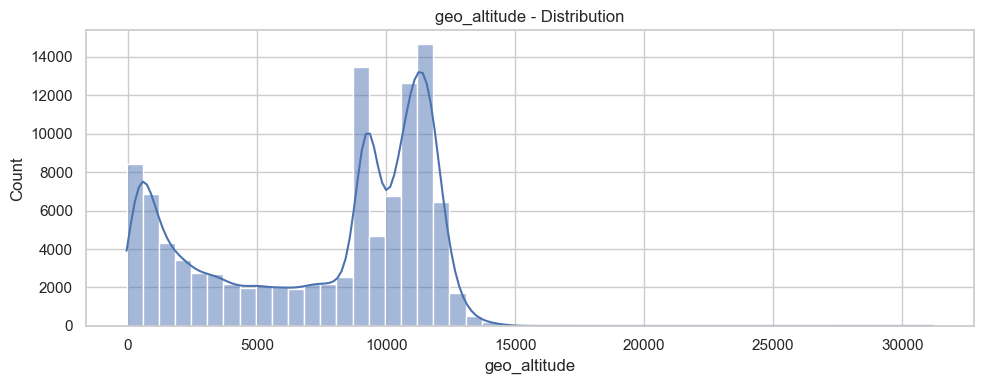

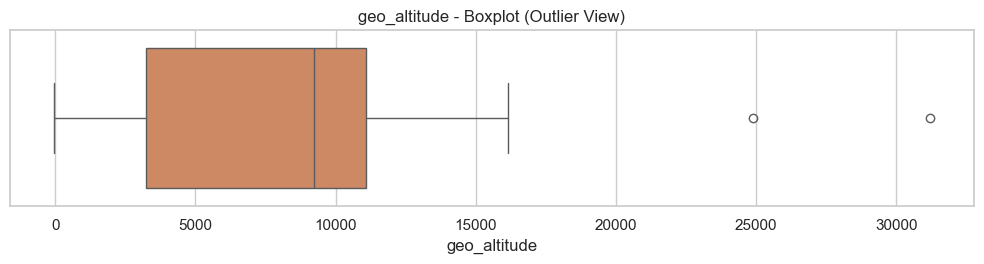

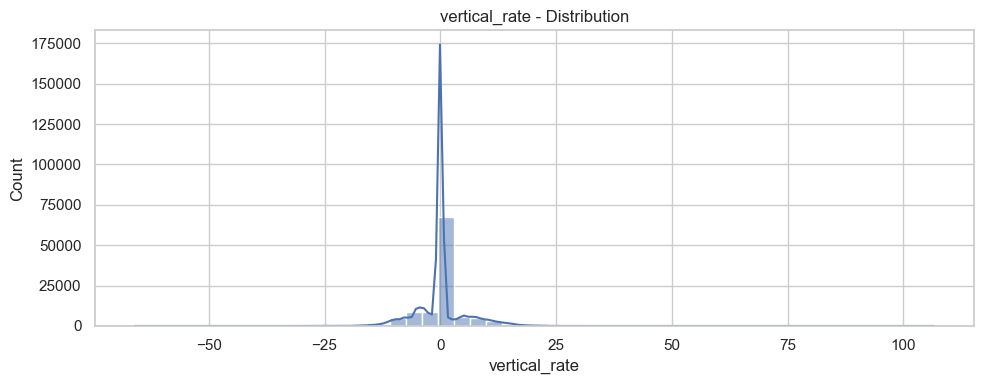

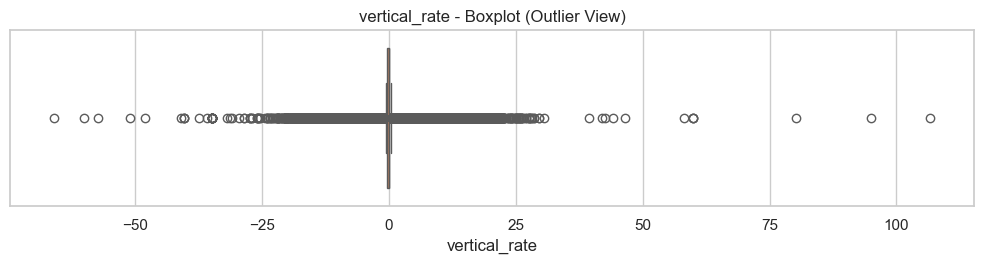

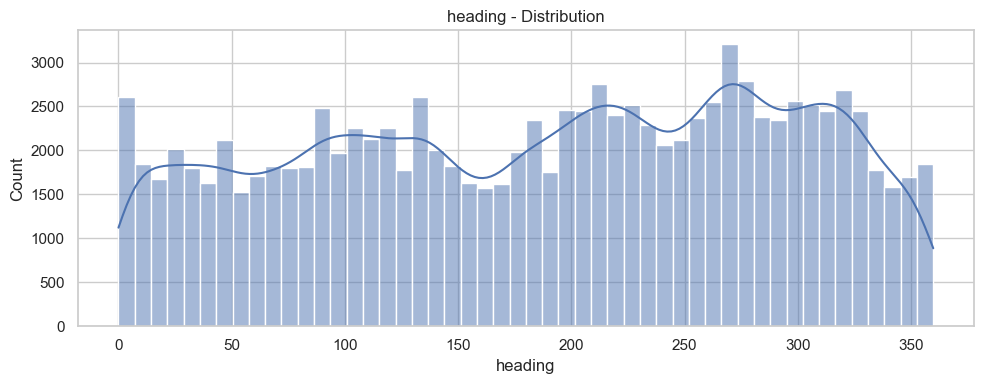

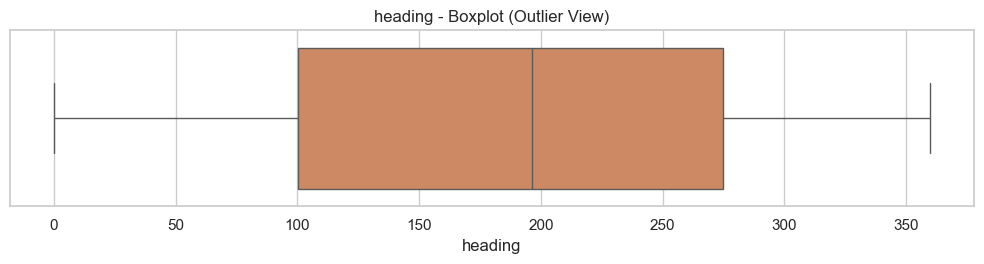

In [8]:

numeric_cols = ['velocity', 'baro_altitude', 'geo_altitude', 'vertical_rate', 'heading']

desc = df[numeric_cols].describe().T
desc['skewness'] = df[numeric_cols].skew()
desc['kurtosis'] = df[numeric_cols].kurtosis()
display(desc)

for col in numeric_cols:
    plt.figure(figsize=(10, 4))
    sns.histplot(df[col], kde=True, color='#4c72b0', bins=50)
    plt.title(f'{col} - Distribution')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 2.8))
    sns.boxplot(x=df[col], color='#dd8452')
    plt.title(f'{col} - Boxplot (Outlier View)')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()


## 8) Outlier Analysis (IQR + Percentile View)

In [9]:

outlier_rows = []

for col in ['velocity', 'baro_altitude', 'geo_altitude', 'vertical_rate']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr

    iqr_mask = (df[col] < low) | (df[col] > high)
    pct_99 = df[col].quantile(0.99)

    trimmed_mean = df.loc[df[col] <= pct_99, col].mean()

    outlier_rows.append({
        'feature': col,
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
        'iqr_low': low,
        'iqr_high': high,
        'iqr_outlier_count': int(iqr_mask.sum()),
        'iqr_outlier_pct': iqr_mask.mean() * 100,
        'p99_threshold': pct_99,
        'mean_original': df[col].mean(),
        'mean_below_p99': trimmed_mean,
        'mean_shift_after_trim': df[col].mean() - trimmed_mean
    })

outlier_summary = pd.DataFrame(outlier_rows).sort_values('iqr_outlier_pct', ascending=False)
display(outlier_summary)


,feature,q1,q3,iqr,iqr_low,iqr_high,iqr_outlier_count,iqr_outlier_pct,p99_threshold,mean_original,mean_below_p99,mean_shift_after_trim
3,vertical_rate,-0.330,0.000,0.330,-0.825,0.495,41963,39.293,15.280,0.079,-0.091,0.171
0,velocity,84.360,228.310,143.950,-131.565,444.235,25,0.023,275.980,162.862,161.495,1.367
2,geo_altitude,"3,238.500","11,094.720","7,856.220","-8,545.830","22,879.050",2,0.002,"12,854.940","7,504.956","7,446.414",58.542
1,baro_altitude,"3,009.900","10,965.180","7,955.280","-8,923.020","22,898.100",0,0.000,"12,496.800","7,239.801","7,201.773",38.029


## 9) Segment Analysis: Airborne vs On-Ground

,on_ground,records,avg_velocity,median_velocity,avg_baro_altitude,avg_geo_altitude,avg_vertical_rate
0,False,97002,178.742,208.670,"7,106.102","7,330.212",0.087
1,True,9793,5.566,2.570,"8,564.127","9,235.838",0.000


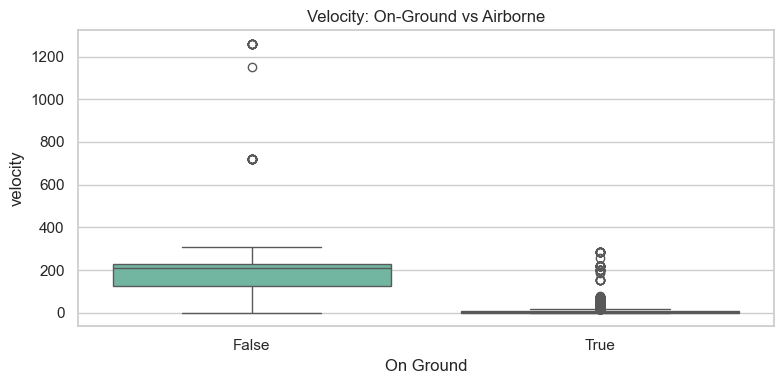

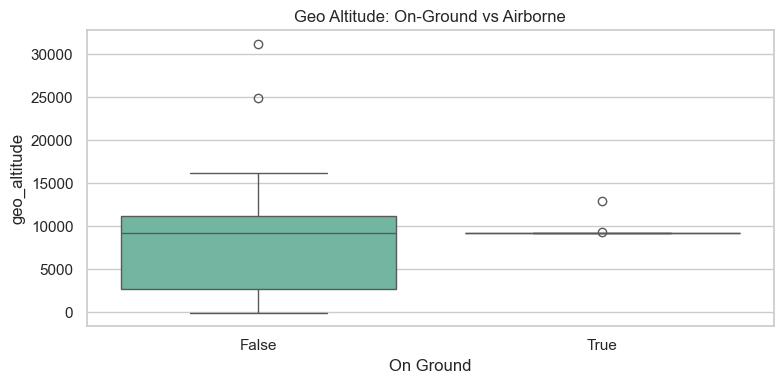

In [10]:

segment = (
    df.groupby('on_ground')
      .agg(
          records=('icao24', 'size'),
          avg_velocity=('velocity', 'mean'),
          median_velocity=('velocity', 'median'),
          avg_baro_altitude=('baro_altitude', 'mean'),
          avg_geo_altitude=('geo_altitude', 'mean'),
          avg_vertical_rate=('vertical_rate', 'mean')
      )
      .reset_index()
)

display(segment)

plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='on_ground', y='velocity', palette='Set2')
plt.title('Velocity: On-Ground vs Airborne')
plt.xlabel('On Ground')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='on_ground', y='geo_altitude', palette='Set2')
plt.title('Geo Altitude: On-Ground vs Airborne')
plt.xlabel('On Ground')
plt.tight_layout()
plt.show()


## 10) Relationship Analysis (Correlation + Scatter)

,velocity,baro_altitude,geo_altitude,vertical_rate,heading,latitude,longitude
velocity,1.000,0.638,0.617,0.039,-0.030,-0.009,0.023
baro_altitude,0.638,1.000,0.981,0.028,0.022,-0.001,0.001
geo_altitude,0.617,0.981,1.000,0.026,0.019,-0.012,0.004
vertical_rate,0.039,0.028,0.026,1.000,0.023,-0.003,-0.035
heading,-0.030,0.022,0.019,0.023,1.000,0.032,0.000
latitude,-0.009,-0.001,-0.012,-0.003,0.032,1.000,-0.295
longitude,0.023,0.001,0.004,-0.035,0.000,-0.295,1.000


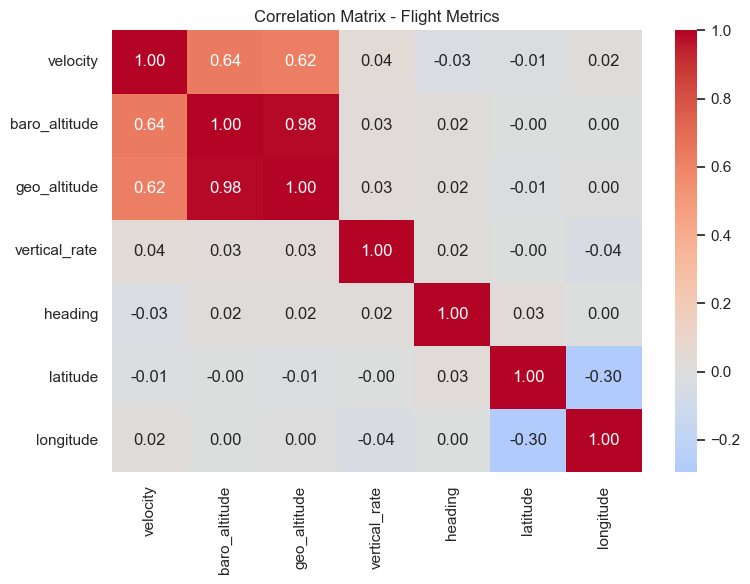

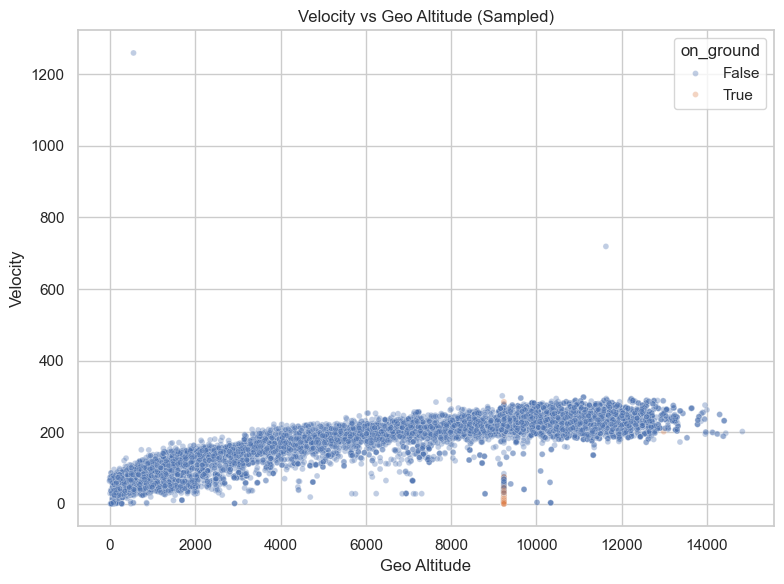

In [11]:

corr_cols = ['velocity', 'baro_altitude', 'geo_altitude', 'vertical_rate', 'heading', 'latitude', 'longitude']
corr = df[corr_cols].corr(numeric_only=True)

display(corr)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix - Flight Metrics')
plt.tight_layout()
plt.show()

sample_scatter = df.sample(min(15000, len(df)), random_state=42)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=sample_scatter,
    x='geo_altitude',
    y='velocity',
    hue='on_ground',
    alpha=0.35,
    s=18
)
plt.title('Velocity vs Geo Altitude (Sampled)')
plt.xlabel('Geo Altitude')
plt.ylabel('Velocity')
plt.tight_layout()
plt.show()



## 11) Key EDA Notes

- Data is dominated by airborne records.
- Velocity and altitude are right-skewed; percentile-based metrics are useful.
- Strong barometric vs geo altitude correlation confirms signal consistency.



## 12) Output

This notebook provides validated exploratory patterns for statistical testing in `04_statistical_analysis.ipynb`.
